# Hotel Booking Demand Analysis
## Explorative Data Analysis
## 2nd Iteration
* **Goal:** Explore booking pattern and cancellation rates

In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Safe Data Loading with try/except

file_path = 'hotel_bookings.csv'
try:
    df = pd.read_csv(file_path)
    print(f'File: {file_path} loaded successfully')
except FileNotFoundError:
    print(f'File not found - check {file_path}')

File: hotel_bookings.csv loaded successfully


In [35]:
# Inspection of Dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [36]:
# Shape of Dataset
print(f'Rows:{df.shape[0]} -- Columns:{df.shape[1]}')

Rows:119390 -- Columns:32


In [37]:
# Check for Dataset Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [38]:
# Check on the statistic metrics
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [39]:
# Check for missing values
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

**Note on Missing Values:**  
In this second iteration, missing values will be handled earlier to support cleaner analysis and visualizations.

* `children`: Missing values will be imputed using the mode for `City Hotel`, since all missing values occur in this hotel type.
* `agent` and `company`: Missing values will be filled with `0`, assuming no agent or company was involved.
* `country`: Missing values will be filled with `UNK` to represent unknown country information.

In [40]:
# Check Duplicates
df.duplicated().sum()

np.int64(31994)

**Note on Duplicates:** Since the dataset is anonymous, there is no unique indicator to tell if identical rows are actual technical duplicates, group bookings, or company bookings. In the first iteration, the EDA included all duplicates. For this second iteration, I will split the dataset into two versions—one with duplicates and one without. This allows me to analyze how the relationships between variables and the overall numbers differ between the two datasets.

## Filling Missing Values

In [41]:
# Create a copy for EDA cleaning
df_eda = df.copy()

In [42]:
# Filling missing values on agent and company with 0 for no agent and no company
df_eda['agent'] = df_eda['agent'].fillna(0)
df_eda['company'] = df_eda['company'].fillna(0)

# Check if it works
print(df_eda[['agent', 'company']].isna().sum())

agent      0
company    0
dtype: int64


In [43]:
# Filling missing values country with UNK for unknown
df_eda['country'] = df_eda['country'].fillna('UNK')

# Check the result
print(df_eda['country'].isna().sum())

0


In [44]:
# Check the hotel with the 4 missing values
print(df_eda[df_eda['children'].isna()])

            hotel  is_canceled  lead_time  arrival_date_year  \
40600  City Hotel            1          2               2015   
40667  City Hotel            1          1               2015   
40679  City Hotel            1          1               2015   
41160  City Hotel            1          8               2015   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
40600             August                        32                          3   
40667             August                        32                          5   
40679             August                        32                          5   
41160             August                        33                         13   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
40600                        1                     0       2  ...   
40667                        0                     2       2  ...   
40679                        0                     2       3  ... 

In [45]:
# Creating variable for input
city_child = df_eda[df_eda['hotel'] == 'City Hotel']['children'].mode()[0]

# Filling the missing values
df_eda['children'] = df_eda['children'].fillna(city_child)

In [46]:
# Check again for missing values
df_eda.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

**Note on Missing Values:**  
After applying the imputation strategy, there are no remaining missing values in the dataset. Next, the dataset will be split into two versions: one including duplicates and one with duplicates removed.

In [47]:
# Creating two different datasets - one with duplicates and one without duplicates
df_eda_with_dup = df_eda.copy()
df_eda_no_dup = df_eda.drop_duplicates()

# Check the shape of both datasets
print(f'Dataset with duplicates: {df_eda_with_dup.shape}')
print(f'Dataset without duplicates: {df_eda_no_dup.shape}')

Dataset with duplicates: (119390, 32)
Dataset without duplicates: (87396, 32)


## Visualisations after filling missing values and splitting dataset

In [55]:
# Checking the cancellation by dataset
print('Cancellation Rate with Duplicates:',round(df_eda_with_dup['is_canceled'].mean()*100,2),'%')
print('Cancellation Rate without Duplicates:', round(df_eda_no_dup['is_canceled'].mean()*100,2),'%')

Cancellation Rate with Duplicates: 37.04 %
Cancellation Rate without Duplicates: 27.49 %


**Note on Duplicate Impact:**
A comparison of both datasets reveals a significant insight: while the full dataset (including duplicates) contains 119,390 entries, the cleaned dataset (excluding duplicates) comprises 87,396 entries. Interestingly, removing these duplicates leads to a drop of 10% in the overall cancellation rate. 

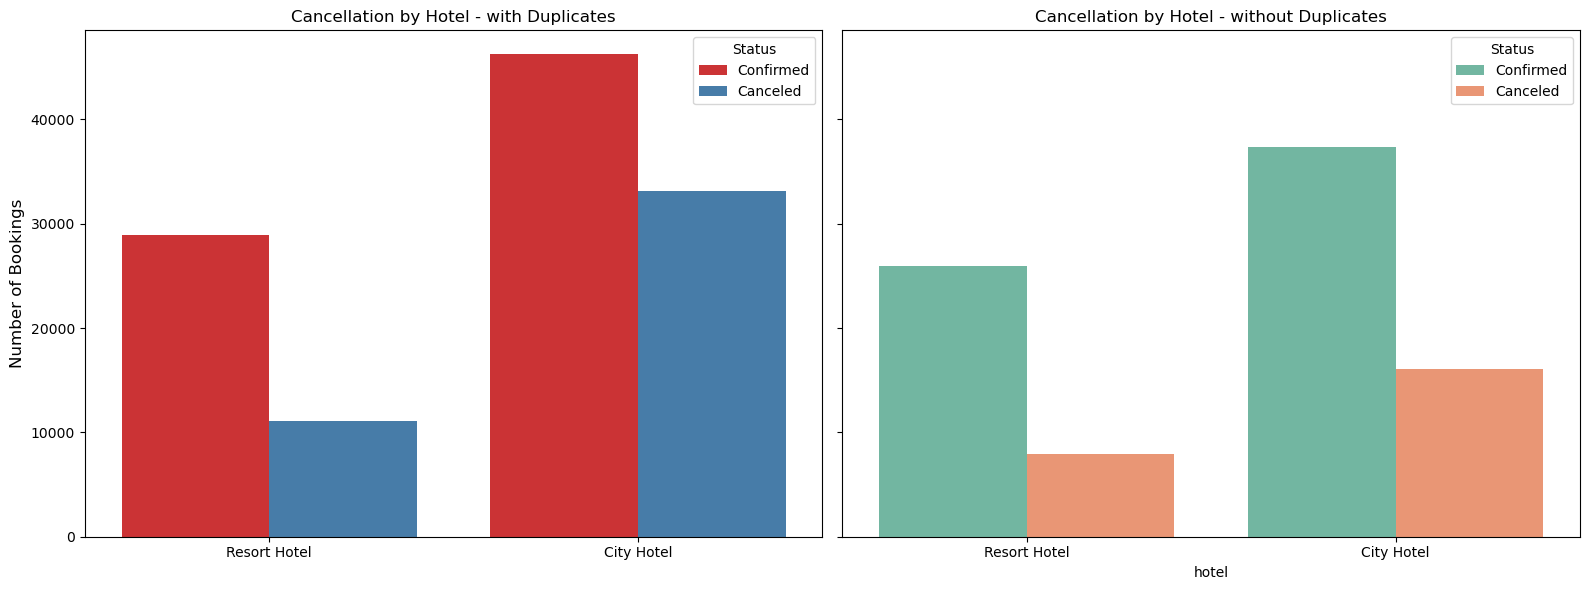

In [56]:
# Visualize the comparison by hotel
fig, axes = plt.subplots(1,2, figsize=(16,6), sharey=True)

sns.countplot(data=df_eda_with_dup, x='hotel', hue='is_canceled', palette='Set1', ax=axes[0])
axes[0].set_title('Cancellation by Hotel - with Duplicates', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Bookings', fontsize=12)
axes[0].legend(title='Status', labels=['Confirmed', 'Canceled'])

sns.countplot(data=df_eda_no_dup, x='hotel', hue='is_canceled', palette='Set2', ax=axes[1])
axes[1].set_title('Cancellation by Hotel - without Duplicates', fontsize=12)
axes[1].legend(title='Status', labels=['Confirmed', 'Canceled'])

plt.tight_layout()
plt.show()

### Analysis of Cancellations by Hotel Type (Dataset Comparison)

* **Consistent Trends:** Both datasets reveal a similar baseline pattern: the City Hotel shows substantially higher cancellation volumes than the Resort Hotel.
* **With Duplicates (Full Dataset):** In the full dataset, City Hotel cancellations exceed 30,000 compared to roughly 50,000 confirmed bookings. This makes cancellations appear more dominant in the operational picture.
* **Without Duplicates (Cleaned Dataset):** After removing 31,994 duplicate entries, City Hotel cancellations drop to around 20,000, while confirmed bookings remain close to 40,000. The City Hotel still has a higher cancellation burden than the Resort Hotel, but the difference appears less inflated than in the full dataset.
* **Key Takeaway:** Removing duplicates changes the overall cancellation rate from 37% to 27%, showing that duplicate records have a meaningful impact on the cancellation analysis.